<a href="https://colab.research.google.com/github/AHMEDVALL70/ahmed-vall-cv/blob/main/ATS_CV_Optimizer_12.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Project 12: ATS-Optimized CV Generator & Analyzer
# Author: Ahmed Vall Jemal Dine Sidina | AHMEDVALL70
# Context: Combining 25+ years of HR & recruitment experience
#          with AI/NLP to help candidates beat Applicant
#          Tracking Systems and land more interviews.
# Goal: Analyze a CV against a job description, calculate
#       ATS compatibility score, suggest improvements, and
#       generate a clean ATS-friendly CV in PDF format.
# Libraries: sklearn · spacy · fpdf2 · re · collections
# Use Cases: Job seekers · HR tools · Recruitment automation

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 81.0/81.0 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 327.1/327.1 kB 3.0 MB/s eta 0:00:00
  ATS-Optimized CV Generator & Analyzer
  Author: Ahmed Vall Jemal Dine Sidina | AHMEDVALL70
Libraries loaded successfully!

Candidate : Ahmed Vall Jemal Dine Sidina
Skills    : 34 skills loaded

  RUNNING ATS COMPATIBILITY ANALYSIS...

           ATS COMPATIBILITY REPORT
  Candidate        : Ahmed Vall Jemal Dine Sidina
  Overall ATS Score: 61.8 / 100
  Grade            : FAIR

  Matched (29): analysis, computer, data, deep, engineer, experience, frameworks, government, language, leadership
  Missing  (1): looking

[STRUCTURE CHECKS]
  [PASS] Has Name
  [PASS] Has Email
  [PASS] Has Phone
  [PASS] Has Summary
  [PASS] Has Experience
  [PASS] Has Education
  [PASS] Has Skills
  [PASS] Summary Length OK
  [PASS] Has 5+ Skills
  [PASS] Has Projects

[SUGGESTIONS]
  1. Add missing keywords to summary/skills: looking
  2. Use standa

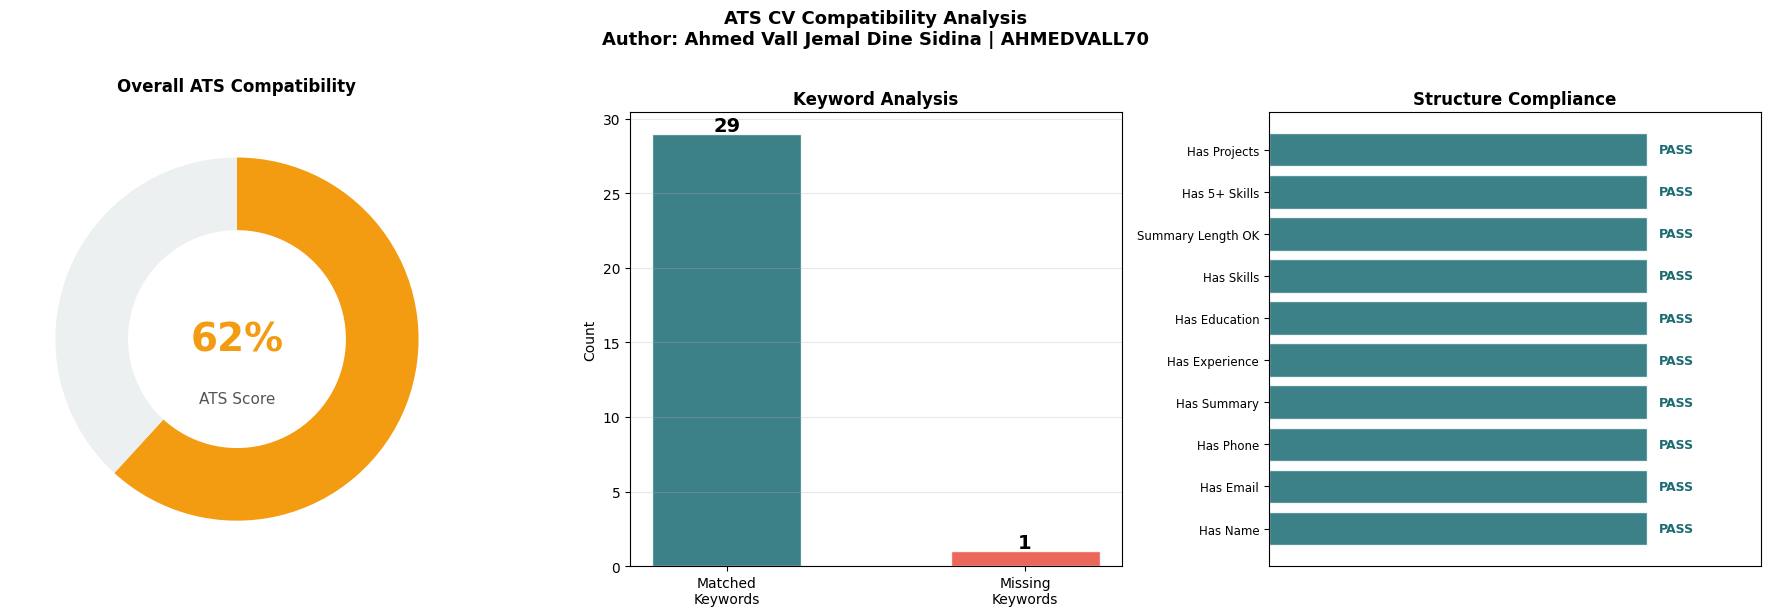

Chart saved!

   PROJECT 12: ATS CV OPTIMIZER - COMPLETE
  ATS Score        : 61.8 / 100
  Keywords Matched : 29
  Keywords Missing : 1
  Structure Checks : 10/10 PASS
  PDF Generated    : ATS_CV_Ahmed_Vall.pdf


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [1]:

# ── INSTALL ──────────────────────────────────────────────
!pip install fpdf2 scikit-learn -q

# ── IMPORTS ──────────────────────────────────────────────
import re
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from fpdf import FPDF

print("=" * 55)
print("  ATS-Optimized CV Generator & Analyzer")
print("  Author: Ahmed Vall Jemal Dine Sidina | AHMEDVALL70")
print("=" * 55)
print("Libraries loaded successfully!\n")

# ── CV DATA ──────────────────────────────────────────────
cv_data = {
    "name": "Ahmed Vall Jemal Dine Sidina",
    "title": "State Engineer | Diplomat | ML Specialist",
    "email": "ahmedvalljemaldine@gmail.com",
    "phone": "+974 7473 6271",
    "location": "Kampala, Uganda",
    "website": "ahmedvall70.github.io/ahmed-vall-cv",
    "summary": (
        "State Engineer (BAC+5) and former diplomat with 25+ years of experience "
        "in biometric systems, civil registry, IT center management, public procurement, "
        "contract negotiation, and computer maintenance. Advanced skills in machine learning, "
        "neural networks, data science, Python programming, natural language processing, "
        "computer vision, and AI solution development. Experienced data scientist and "
        "ML frameworks specialist with background in supervising IT computer centers."
    ),
    "experience": [
        {
            "title": "Deputy Consul General",
            "company": "Consulate General of Mauritania, Jeddah, Saudi Arabia",
            "date": "2019 - 2024",
            "bullets": [
                "Supervised civil status services and issuance of biometric identity documents",
                "Managed digital transformation of consular workflows and documentation systems",
                "Coordinated bilateral administrative matters with Saudi government authorities",
                "Led team of administrative staff serving thousands of citizens annually",
            ]
        },
        {
            "title": "Director of Secure Document Authentication",
            "company": "ANRPTS - National Agency for Population Registry, Mauritania",
            "date": "2015 - 2019",
            "bullets": [
                "Directed national biometric registry center and secure document infrastructure",
                "Managed IT center operations and supervised technical maintenance teams",
                "Oversaw biometric passport, national ID, residence permit, and visa issuance",
                "Implemented quality control protocols for secure document production",
            ]
        },
        {
            "title": "Member - Internal Procurement Committee (CIMAC)",
            "company": "ANRPTS - National Agency for Population Registry, Mauritania",
            "date": "2016 - 2018",
            "bullets": [
                "Reviewed and approved procurement contracts in compliance with national standards",
                "Ensured transparency and integrity in government tendering processes",
            ]
        },
        {
            "title": "Public Procurement Officer",
            "company": "National HIV/AIDS Control Program - Eastern Basin, Mauritania",
            "date": "2005 - 2011",
            "bullets": [
                "Managed procurement operations and contract negotiations for national health program",
                "Ensured compliance with national and international procurement standards",
                "Coordinated with World Bank-supervised international partners and donors",
            ]
        },
        {
            "title": "Secretary General",
            "company": "Al-Mabrouk Municipality - Nema Province, Mauritania",
            "date": "2006 - 2011",
            "bullets": [
                "Managed all administrative and financial operations of the municipality",
                "Supervised local governance affairs and public service delivery",
                "Coordinated with regional government authorities on administrative matters",
            ]
        },
        {
            "title": "IT Center Supervisor & Computer Maintenance Engineer",
            "company": "Dar Al-Computer - Nema, Ayoun, Kiffa, Aleg, Boghe, Kaedi, Selibaby",
            "date": "2002 - 2005",
            "bullets": [
                "Supervised computer centers across 7 cities in multiple Mauritanian regions",
                "Managed LAN/WAN network installation, configuration, and maintenance",
                "Performed hardware and software computer maintenance for government IT infrastructure",
                "Delivered computer training programs for government staff on PADEL and PDRC projects",
            ]
        },
        {
            "title": "Maintenance Engineer & IT Trainer",
            "company": "Star Technologies & Perfect Consult Bureau, Mauritania",
            "date": "2003 - 2008",
            "bullets": [
                "Maintenance engineer and trainer for PADEL and PDRC projects across multiple regions",
                "Responsible for computer maintenance, training and network installation",
                "Trained Peace Corps volunteers on Small Business Program in Kaedi",
            ]
        },
        {
            "title": "IT Trainer",
            "company": "Iqraa Institute - Nouakchott, Mauritania",
            "date": "2000 - 2002",
            "bullets": [
                "Delivered IT and digital literacy training programs for adult learners",
            ]
        },
    ],
    "education": [
        {"degree": "State Engineer in Electronics & Digital Development (BAC+5)", "school": "5-year Engineering Program", "year": "1992-1997"},
        {"degree": "Machine Learning Specialization", "school": "Stanford / Coursera", "year": "2025"},
        {"degree": "Deep Learning Specialization", "school": "DeepLearning.AI / Coursera", "year": "2025"},
        {"degree": "Python for Data Science & AI", "school": "IBM", "year": "2024"},
        {"degree": "Diploma in Business Administration", "school": "United Academy for Training Management", "year": "2021"},
    ],
    "skills": [
        "Python", "Machine Learning", "Deep Learning", "TensorFlow", "Scikit-learn",
        "NLP", "Computer Vision", "OpenCV", "Data Analysis", "Pandas", "NumPy",
        "Biometric Systems", "IT Management", "Cisco Networking", "Cybersecurity",
        "Public Procurement", "Contract Negotiation", "Digital Diplomacy",
        "Strategic Planning", "Team Leadership", "Project Management",
        "neural networks", "statistical modeling", "communication",
        "government", "security", "data science", "computer maintenance",
        "hardware maintenance", "network installation", "IT training",
        "LAN WAN", "technical support", "natural language processing",
    ],
    "languages": [
        {"lang": "Arabic", "level": "Native"},
        {"lang": "French", "level": "Full Professional"},
        {"lang": "English", "level": "Intermediate"},
    ],
    "projects": [
        "01 - Diabetes Prediction | Classification ML (Scikit-learn)",
        "02 - Iris Flower Classification | KNN Model",
        "03 - Gemini AI Integration | Google AI API",
        "04 - Sentiment Analyzer | NLP + TextBlob",
        "05 - Exchange Rate Tracker | Uganda Market Analysis",
        "06 - Saudi Real Estate Predictor | Random Forest",
        "07 - Spam Mail Classifier | NLP Text Classification",
        "08 - Handwritten Digit Classifier | CNN Neural Network",
        "09 - Crypto Price Predictor | LSTM Deep Learning",
        "10 - Arabic Sentiment Analysis | NLP + Prompt Engineering",
        "11 - Procurement Fraud Detection | Isolation Forest",
        "12 - ATS CV Optimizer | TF-IDF + Cosine Similarity",
    ]
}

# ── JOB DESCRIPTION ──────────────────────────────────────
job_description = """
We are looking for a Machine Learning Engineer / Data Scientist with experience in:
- Python programming and machine learning frameworks (TensorFlow, Scikit-learn)
- Natural Language Processing (NLP) and computer vision
- Data analysis and statistical modeling
- Deep learning and neural networks
- Project management and team leadership
- Experience with government or public sector projects preferred
- Knowledge of cybersecurity and data security
- Strong communication skills in English and Arabic
- Experience in procurement or contract management is a plus
Qualifications: Bachelor degree or higher in Computer Science, Engineering, or related field.
"""

print(f"Candidate : {cv_data['name']}")
print(f"Skills    : {len(cv_data['skills'])} skills loaded\n")

# ── ATS ANALYZER ─────────────────────────────────────────
class ATSAnalyzer:
    def __init__(self, cv_data, job_description):
        self.cv = cv_data
        self.job = job_description
        self.cv_text = self._extract_cv_text()
        self.results = {}

    def _extract_cv_text(self):
        parts = [
            self.cv.get('summary', ''),
            ' '.join(self.cv.get('skills', [])),
            ' '.join(self.cv.get('projects', [])),
        ]
        for exp in self.cv.get('experience', []):
            parts.append(exp.get('title', ''))
            parts.extend(exp.get('bullets', []))
        for edu in self.cv.get('education', []):
            parts.append(edu.get('degree', ''))
        return ' '.join(parts).lower()

    def _extract_keywords(self, text, top_n=25):
        stop_words = {
            'and','or','the','a','an','in','of','for','to','with','is','are',
            'we','our','you','your','will','be','have','has','that','this',
            'at','by','from','as','on','it','its','not','but','if','plus',
        }
        words = re.findall(r'\b[a-zA-Z]{3,}\b', text.lower())
        filtered = [w for w in words if w not in stop_words]
        return [word for word, _ in Counter(filtered).most_common(top_n)]

    def calculate_similarity_score(self):
        vectorizer = TfidfVectorizer(stop_words='english', ngram_range=(1, 2))
        try:
            matrix = vectorizer.fit_transform([self.cv_text, self.job.lower()])
            return round(cosine_similarity(matrix[0:1], matrix[1:2])[0][0] * 100, 1)
        except:
            return 0.0

    def find_matching_keywords(self):
        job_kw = set(self._extract_keywords(self.job, 30))
        cv_words = set(re.findall(r'\b[a-zA-Z]{3,}\b', self.cv_text))
        return sorted(job_kw & cv_words), sorted(job_kw - cv_words)

    def check_ats_structure(self):
        return {
            'Has Name':          bool(self.cv.get('name')),
            'Has Email':         bool(self.cv.get('email')),
            'Has Phone':         bool(self.cv.get('phone')),
            'Has Summary':       bool(self.cv.get('summary')),
            'Has Experience':    len(self.cv.get('experience', [])) > 0,
            'Has Education':     len(self.cv.get('education', [])) > 0,
            'Has Skills':        len(self.cv.get('skills', [])) >= 5,
            'Summary Length OK': len(self.cv.get('summary', '').split()) >= 30,
            'Has 5+ Skills':     len(self.cv.get('skills', [])) >= 5,
            'Has Projects':      len(self.cv.get('projects', [])) > 0,
        }

    def generate_suggestions(self, missing_keywords):
        suggestions = []
        if missing_keywords:
            suggestions.append(f"Add missing keywords to summary/skills: {', '.join(list(missing_keywords)[:8])}")
        if len(self.cv.get('skills', [])) < 15:
            suggestions.append("Add more technical skills relevant to the job posting.")
        if len(self.cv.get('summary', '').split()) < 50:
            suggestions.append("Expand your professional summary to at least 50 words.")
        suggestions.append("Use standard section headers: Experience, Education, Skills.")
        suggestions.append("Avoid tables, images, and columns — ATS systems cannot read them.")
        suggestions.append("Save CV as .docx or simple .pdf — avoid fancy formatting.")
        return suggestions

    def run_full_analysis(self):
        print("=" * 60)
        print("  RUNNING ATS COMPATIBILITY ANALYSIS...")
        print("=" * 60)
        score = self.calculate_similarity_score()
        self.results['score'] = score
        matched, missing = self.find_matching_keywords()
        self.results['matched_keywords'] = matched
        self.results['missing_keywords'] = missing
        structure = self.check_ats_structure()
        self.results['structure'] = structure
        struct_score = sum(structure.values()) / len(structure) * 100
        self.results['suggestions'] = self.generate_suggestions(missing)
        overall = round((score * 0.5) + (struct_score * 0.3) + (min(len(matched), 10) * 2), 1)
        self.results['overall'] = min(overall, 100)
        return self.results

    def print_report(self):
        r = self.results
        print("\n" + "=" * 60)
        print("           ATS COMPATIBILITY REPORT")
        print("=" * 60)
        print(f"  Candidate        : {self.cv['name']}")
        print(f"  Overall ATS Score: {r['overall']:.1f} / 100")
        s = r['overall']
        grade = "EXCELLENT" if s >= 80 else "GOOD" if s >= 65 else "FAIR" if s >= 50 else "POOR"
        print(f"  Grade            : {grade}")
        print(f"\n  Matched ({len(r['matched_keywords'])}): {', '.join(r['matched_keywords'][:10])}")
        print(f"  Missing  ({len(r['missing_keywords'])}): {', '.join(r['missing_keywords'][:8])}")
        print("\n[STRUCTURE CHECKS]")
        for check, passed in r['structure'].items():
            print(f"  {'[PASS]' if passed else '[FAIL]'} {check}")
        print("\n[SUGGESTIONS]")
        for i, s in enumerate(r['suggestions'], 1):
            print(f"  {i}. {s}")
        print("=" * 60)

# Run analysis
analyzer = ATSAnalyzer(cv_data, job_description)
results = analyzer.run_full_analysis()
analyzer.print_report()

# ── CHARTS ───────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle(
    'ATS CV Compatibility Analysis\n'
    'Author: Ahmed Vall Jemal Dine Sidina | AHMEDVALL70',
    fontsize=13, fontweight='bold', y=1.02
)

# Chart 1: Score Gauge
ax1 = axes[0]
score = results['overall']
color = '#2ecc71' if score >= 80 else '#f39c12' if score >= 60 else '#e74c3c'
ax1.pie([score, 100-score], colors=[color, '#ecf0f1'],
        startangle=90, counterclock=False, wedgeprops={'width': 0.4})
ax1.text(0, 0, f'{score:.0f}%', ha='center', va='center',
         fontsize=28, fontweight='bold', color=color)
ax1.text(0, -0.35, 'ATS Score', ha='center', fontsize=11, color='#555')
ax1.set_title('Overall ATS Compatibility', fontweight='bold', pad=15)

# Chart 2: Keywords Bar
ax2 = axes[1]
matched_n = len(results['matched_keywords'])
missing_n = len(results['missing_keywords'])
bars = ax2.bar(['Matched\nKeywords', 'Missing\nKeywords'],
               [matched_n, missing_n],
               color=['#1a6b72', '#e74c3c'], width=0.5, edgecolor='white', alpha=0.85)
ax2.set_title('Keyword Analysis', fontweight='bold')
ax2.set_ylabel('Count')
ax2.grid(True, alpha=0.3, axis='y')
for bar, val in zip(bars, [matched_n, missing_n]):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
             str(val), ha='center', fontweight='bold', fontsize=14)

# Chart 3: Structure Checks
ax3 = axes[2]
checks = results['structure']
y_pos = np.arange(len(checks))
values = [1 if v else 0 for v in checks.values()]
colors_bar = ['#1a6b72' if v else '#e74c3c' for v in values]
bars3 = ax3.barh(y_pos, values, color=colors_bar, alpha=0.85, edgecolor='white')
ax3.set_yticks(y_pos)
ax3.set_yticklabels(list(checks.keys()), fontsize=8.5)
ax3.set_xlim(0, 1.3)
ax3.set_title('Structure Compliance', fontweight='bold')
ax3.set_xticks([])
for bar, val in zip(bars3, values):
    ax3.text(val + 0.03, bar.get_y() + bar.get_height()/2,
             'PASS' if val else 'FAIL', va='center', fontsize=9,
             fontweight='bold', color='#1a6b72' if val else '#e74c3c')

plt.tight_layout()
plt.savefig('ats_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved!")

# ── GENERATE ATS PDF CV ───────────────────────────────────
class ATSFriendlyCV(FPDF):
    def footer(self):
        self.set_y(-12)
        self.set_font('Helvetica', '', 7)
        self.set_text_color(150, 150, 150)
        self.cell(0, 5, 'ahmedvall70.github.io/ahmed-vall-cv  |  ahmedvalljemaldine@gmail.com  |  +974 7473 6271', align='C')

    def section_title(self, title):
        self.ln(4)
        self.set_font('Helvetica', 'B', 11)
        self.set_text_color(26, 107, 114)
        self.cell(0, 7, title.upper(), new_x="LMARGIN", new_y="NEXT")
        self.set_draw_color(26, 107, 114)
        self.set_line_width(0.5)
        self.line(self.get_x(), self.get_y(), self.get_x() + 170, self.get_y())
        self.ln(2)
        self.set_text_color(0, 0, 0)

    def add_bullet(self, text):
        self.set_font('Helvetica', '', 9)
        self.set_text_color(50, 50, 50)
        x = self.get_x()
        self.set_x(x + 5)
        self.multi_cell(0, 5, f'* {text}')
        self.set_x(x)

pdf = ATSFriendlyCV()
pdf.add_page()
pdf.set_auto_page_break(auto=True, margin=15)
pdf.set_margins(20, 15, 20)

# Header
pdf.set_font('Helvetica', 'B', 20)
pdf.set_text_color(26, 107, 114)
pdf.cell(0, 10, cv_data['name'], new_x="LMARGIN", new_y="NEXT", align='C')
pdf.set_font('Helvetica', '', 10)
pdf.set_text_color(100, 100, 100)
pdf.cell(0, 5, cv_data['title'], new_x="LMARGIN", new_y="NEXT", align='C')
pdf.set_font('Helvetica', '', 9)
contact = f"{cv_data['phone']}  |  {cv_data['email']}  |  {cv_data['website']}  |  {cv_data['location']}"
pdf.cell(0, 5, contact, new_x="LMARGIN", new_y="NEXT", align='C')
pdf.set_draw_color(201, 168, 76)
pdf.set_line_width(0.8)
pdf.line(20, pdf.get_y() + 2, 190, pdf.get_y() + 2)
pdf.ln(5)

# Summary
pdf.section_title('Professional Summary')
pdf.set_font('Helvetica', '', 9.5)
pdf.set_text_color(40, 40, 40)
pdf.multi_cell(0, 5.5, cv_data['summary'])
pdf.ln(2)

# Experience
pdf.section_title('Professional Experience')
for exp in cv_data['experience']:
    pdf.set_font('Helvetica', 'B', 10)
    pdf.set_text_color(28, 28, 30)
    pdf.cell(0, 6, exp['title'], new_x="LMARGIN", new_y="NEXT")
    pdf.set_font('Helvetica', '', 9)
    pdf.set_text_color(26, 107, 114)
    pdf.cell(120, 5, exp['company'])
    pdf.set_text_color(201, 168, 76)
    pdf.cell(0, 5, exp['date'], align='R', new_x="LMARGIN", new_y="NEXT")
    for bullet in exp['bullets']:
        pdf.add_bullet(bullet)
    pdf.ln(2)

# Education
pdf.section_title('Education & Certifications')
for edu in cv_data['education']:
    pdf.set_font('Helvetica', 'B', 9.5)
    pdf.set_text_color(28, 28, 30)
    pdf.cell(140, 5, edu['degree'])
    pdf.set_font('Helvetica', '', 9)
    pdf.set_text_color(201, 168, 76)
    pdf.cell(0, 5, edu['year'], align='R', new_x="LMARGIN", new_y="NEXT")
    pdf.set_font('Helvetica', '', 9)
    pdf.set_text_color(100, 100, 100)
    pdf.cell(0, 4, edu['school'], new_x="LMARGIN", new_y="NEXT")
    pdf.ln(1)

# Skills
pdf.section_title('Technical Skills')
pdf.set_font('Helvetica', '', 9.5)
pdf.set_text_color(40, 40, 40)
skills = cv_data['skills']
for i in range(0, len(skills), 4):
    pdf.cell(0, 5, '  *  '.join(skills[i:i+4]), new_x="LMARGIN", new_y="NEXT")
pdf.ln(2)

# Projects
pdf.section_title('ML Projects (GitHub)')
for proj in cv_data['projects']:
    pdf.add_bullet(proj)
pdf.ln(2)

# Languages
pdf.section_title('Languages')
for lang in cv_data['languages']:
    pdf.set_font('Helvetica', '', 9.5)
    pdf.set_text_color(40, 40, 40)
    pdf.cell(0, 5, f"  *  {lang['lang']} - {lang['level']}", new_x="LMARGIN", new_y="NEXT")

pdf.output('ATS_CV_Ahmed_Vall.pdf')

# ── FINAL SUMMARY ─────────────────────────────────────────
print("\n" + "=" * 60)
print("   PROJECT 12: ATS CV OPTIMIZER - COMPLETE")
print("=" * 60)
print(f"  ATS Score        : {results['overall']:.1f} / 100")
print(f"  Keywords Matched : {len(results['matched_keywords'])}")
print(f"  Keywords Missing : {len(results['missing_keywords'])}")
print(f"  Structure Checks : {sum(results['structure'].values())}/{len(results['structure'])} PASS")
print(f"  PDF Generated    : ATS_CV_Ahmed_Vall.pdf")
print("=" * 60)
from google.colab import files
files.download('ATS_CV_Ahmed_Vall.pdf')